# Sampling of the Rosenbrock distribution

In [17]:
import torch
from torch import Tensor
from geodesic_toolbox.cometric import RosenbrockHessian,RosenbrockSoftAbs, RosenbrockScore, RosenbrockRanders, RosenbrockDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased, ImplicitFHMCLegendre
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In this notebook we aim at benchmarking how our method, FHMC, performs on the sampling of the Rosenbrock distribution : 

\begin{equation}
    \pi(x,y) \propto \exp(-[100(y-x^2)^2+(1-x)^2]/20)
\end{equation}



In [18]:
def rosenborck(z : Tensor) -> Tensor : 
    x = z[:, 0]
    y = z[:, 1]
    return torch.exp(-(100*(y-x**2)**2+(1-x)**2)/20)

## Riemannian Hamiltonian Monte Carlo Sampling

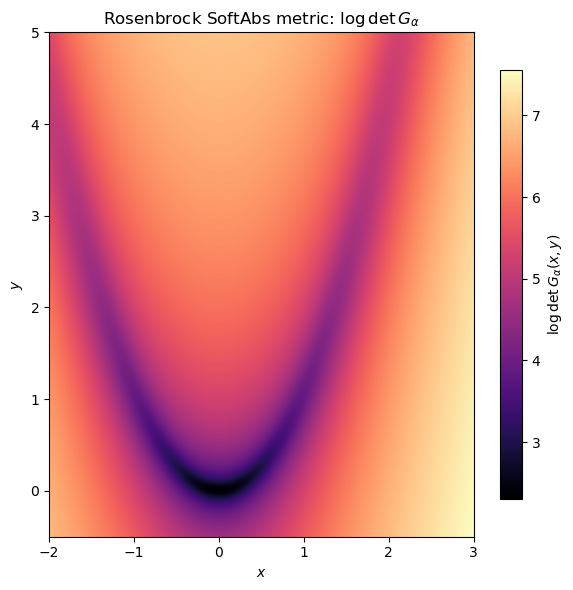

In [19]:
grid_fine = 400
xg = np.linspace(-2, 3, grid_fine)
yg = np.linspace(-0.5, 5, grid_fine)
xx, yy = np.meshgrid(xg, yg)

pts = torch.tensor(
    np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32
)

cometric = RosenbrockSoftAbs()
with torch.no_grad():
    G = cometric.metric_tensor(pts)
    det_G = torch.linalg.det(G).numpy()

log_det_G = np.log(det_G).reshape(grid_fine, grid_fine)

# Rosenbrock log-density for contour overlay
log_pi = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
)

# # Density contours as white lines for context
# levels = np.linspace(log_pi.max() - 6, log_pi.max(), 8)
# ax.contour(xx, yy, log_pi, levels=levels, colors="white", linewidths=0.6, alpha=0.6)

fig.colorbar(im, ax=ax, label=r"$\log \det G_{\alpha}(x, y)$", shrink=0.85)
ax.set_title(r"Rosenbrock SoftAbs metric: $\log \det G_{\alpha}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()


### Definition of the sampler

In [34]:
class RosenbrockRHMC(ImplicitRHMCSampler):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int, std_0: float = 1, bounds: float = 1000, beta_0: float = 1, pbar: bool = False, skip_acceptance: bool = False, threshold_fx: float = 0.00001, alpha : float = 1.):
        cometric = RosenbrockSoftAbs(alpha)
        super().__init__(cometric, l, N_fx, gamma, N_run, std_0, bounds, beta_0, pbar, skip_acceptance, threshold_fx)
    
    def U(self, z):
        x = z[:, 0]
        y = z[:, 1]
        return (100*(y-x**2)**2+(1-x)**2)/20

In [35]:
l = 5
N_fx = 6
gamma = 0.12
N_run = 1000

sampler = RosenbrockRHMC(
    l, 
    N_fx, 
    gamma, 
    N_run,
    pbar = True
)

### Sampling a trajectory

In [36]:
n_traj = 50
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
traj_rhmc, acc_rhmc = sampler.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True
    )
print(f"Acceptance rate: {acc_rhmc:.4f}")

Sampling: 100%|██████████| 1000/1000 [01:07<00:00, 14.88steps/s, acceptance_rate=0.512]


Acceptance rate: 0.5117


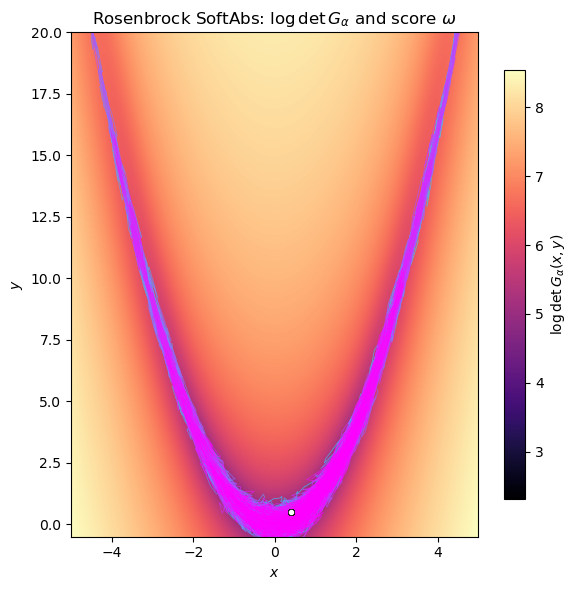

In [39]:
grid_fine   = 400
grid_coarse = 18

xg = np.linspace(-5, 5, grid_fine)
yg = np.linspace(-0.5, 20, grid_fine)
xx, yy = np.meshgrid(xg, yg)

xg_c = np.linspace(-5, 5, grid_coarse)
yg_c = np.linspace(-0.5, 20, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)

pts_fine   = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
pts_coarse = torch.tensor(pts_c_flat, dtype=torch.float32)

score  = RosenbrockScore()
cometric = RosenbrockSoftAbs()

with torch.no_grad():
    G         = cometric.metric_tensor(pts_fine)
    det_G     = torch.linalg.det(G).numpy()
    score_vecs = score(pts_coarse).detach().numpy()

log_det_G = np.log(det_G).reshape(grid_fine, grid_fine)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
)

# --- Trajectories ---
colors = cm.cool(np.linspace(0.2, 1.0, traj_rhmc.shape[0]))
for i in range(traj_rhmc.shape[0]):
    ax.plot(traj_rhmc[i, :, 0].numpy(), traj_rhmc[i, :, 1].numpy(),
            c=colors[i], linewidth=0.6, alpha=0.7)

ax.scatter(traj_rhmc[:, 0, 0].numpy(), traj_rhmc[:, 0, 1].numpy(),
           c="white", s=20, zorder=5, edgecolors="black", linewidths=0.5)

fig.colorbar(im, ax=ax, label=r"$\log \det G_{\alpha}(x, y)$", shrink=0.85)
ax.set_title(r"Rosenbrock SoftAbs: $\log \det G_{\alpha}$ and score $\omega$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

## Finsler Randers Hamiltonian Monte Carlo Sampling

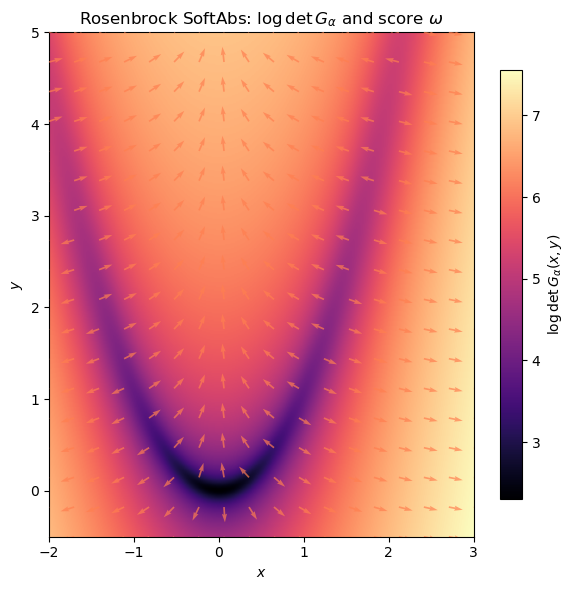

In [24]:
grid_fine   = 400
grid_coarse = 18

xg = np.linspace(-2, 3, grid_fine)
yg = np.linspace(-0.5, 5, grid_fine)
xx, yy = np.meshgrid(xg, yg)

xg_c = np.linspace(-2, 3, grid_coarse)
yg_c = np.linspace(-0.5, 5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)

pts_fine   = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
pts_coarse = torch.tensor(pts_c_flat, dtype=torch.float32)

score    = RosenbrockScore()
cometric = RosenbrockSoftAbs()

with torch.no_grad():
    G          = cometric.metric_tensor(pts_fine)
    det_G      = torch.linalg.det(G).numpy()
    score_vecs = score(pts_coarse).detach().numpy()

log_det_G = np.log(det_G).reshape(grid_fine, grid_fine)

# Normalize to unit length — show direction only
norms = np.linalg.norm(score_vecs, axis=1, keepdims=True)
score_vecs_unit = score_vecs / (norms + 1e-8)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
)

ax.quiver(
    pts_c_flat[:, 0], pts_c_flat[:, 1],
    score_vecs_unit[:, 0], score_vecs_unit[:, 1],
    color="coral", alpha=0.7, zorder=3,
    angles="xy", scale_units="xy", scale=6, width=0.004,
)

fig.colorbar(im, ax=ax, label=r"$\log \det G_{\alpha}(x, y)$", shrink=0.85)
ax.set_title(r"Rosenbrock SoftAbs: $\log \det G_{\alpha}$ and score $\omega$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()


### Definition of the sampler

In [25]:
class RosenbrockFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True, alpha: float = 1., beta : float = 1.):
        randers_cometric = RosenbrockDualRanders(alpha=alpha, beta = beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, z):
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # F* without re-eigh
        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2     # avoid the throw-away outer sqrt

        # BH terms via one Cholesky of G* (G* is already in hand)
        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)


    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # ── logdet G* and α_s via one Cholesky of G* ──────────────────────────
        L             = torch.linalg.cholesky(G_star)
        y             = torch.linalg.solve_triangular(
                            L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq          = torch.einsum("bi,bi->b", y, y)   # |ω*|²_{G*⁻¹} = 1 – α_s
        alpha_s       = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        # BCS identity: det G · det G* = α_s^{–(d+1)}
        #   ⟹ ½(d+1) log α_s + ½ log det G = –½ log det G*
        log_sigma_BH  = -0.5 * logdet_G_star

        # ── momentum scalars, without materialising G* ────────────────────────
        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)   # p^T G^{-1} p
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)          # ω* · p

        # p^T G* p = (ω*·p)² + p^T G^{-1} p / α_s   (from the MDL form of G*)
        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )


### Unbiased sampler without reduced flips

In [26]:
l = 5
N_fx = 6
gamma = 0.12
N_run = 1000
beta = 0.2

sampler_unbiased = RosenbrockFHMCUnbiased(
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta,
    reduced_flip = False
)

In [27]:
n_traj = 50
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
traj_fhmc, acc_fhmc, flip_fhmc = sampler_unbiased.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc:.4f}")
print(f"Momentum flip rate: {flip_fhmc:.4f}")

Sampling: 100%|██████████| 1000/1000 [01:42<00:00,  9.72steps/s, acceptance_rate=0.819]


Acceptance rate: 0.8189
Momentum flip rate: 0.1811


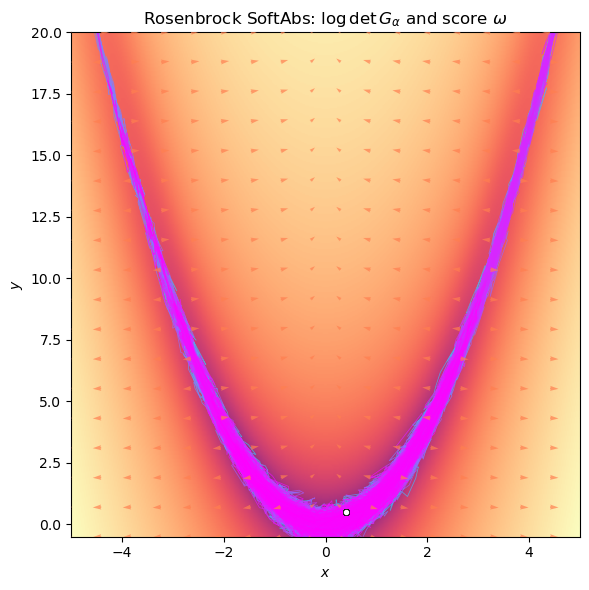

In [28]:
grid_fine   = 400
grid_coarse = 18

xg = np.linspace(-5, 5, grid_fine)
yg = np.linspace(-0.5, 20, grid_fine)
xx, yy = np.meshgrid(xg, yg)

xg_c = np.linspace(-5, 5, grid_coarse)
yg_c = np.linspace(-0.5, 20, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)

pts_fine   = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
pts_coarse = torch.tensor(pts_c_flat, dtype=torch.float32)

score    = RosenbrockScore()
cometric = RosenbrockSoftAbs()

with torch.no_grad():
    G          = cometric.metric_tensor(pts_fine)
    det_G      = torch.linalg.det(G).numpy()
    score_vecs = score(pts_coarse).detach().numpy()

log_det_G = np.log(det_G).reshape(grid_fine, grid_fine)

norms = np.linalg.norm(score_vecs, axis=1, keepdims=True)
score_vecs_unit = score_vecs / (norms + 1e-8)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
)

ax.quiver(
    pts_c_flat[:, 0], pts_c_flat[:, 1],
    score_vecs_unit[:, 0], score_vecs_unit[:, 1],
    color="coral", alpha=0.7, zorder=3,
    angles="xy", scale_units="xy", scale=6, width=0.004,
)

# --- Trajectories ---
colors = cm.cool(np.linspace(0.2, 1.0, traj_fhmc.shape[0]))
for i in range(traj_fhmc.shape[0]):
    ax.plot(traj_fhmc[i, :, 0].numpy(), traj_fhmc[i, :, 1].numpy(),
            c=colors[i], linewidth=0.6, alpha=0.7)

ax.scatter(traj_fhmc[:, 0, 0].numpy(), traj_fhmc[:, 0, 1].numpy(),
           c="white", s=20, zorder=5, edgecolors="black", linewidths=0.5)

ax.set_title(r"Rosenbrock SoftAbs: $\log \det G_{\alpha}$ and score $\omega$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

### Unbiased Sampler with reduced flip

In [29]:
l = 5
N_fx = 6
gamma = 0.12
N_run = 1000
beta = 0.2

sampler_unbiased_rf = RosenbrockFHMCUnbiased(
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta
)

In [30]:
n_traj = 50
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
traj_fhmc_rf, acc_fhmc_rf, flip_fhmc_rf = sampler_unbiased_rf.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc_rf:.4f}")
print(f"Momentum flip rate: {flip_fhmc_rf:.4f}")

Sampling: 100%|██████████| 1000/1000 [03:09<00:00,  5.27steps/s, acceptance_rate=0.8] 

Acceptance rate: 0.8000
Momentum flip rate: 0.1473


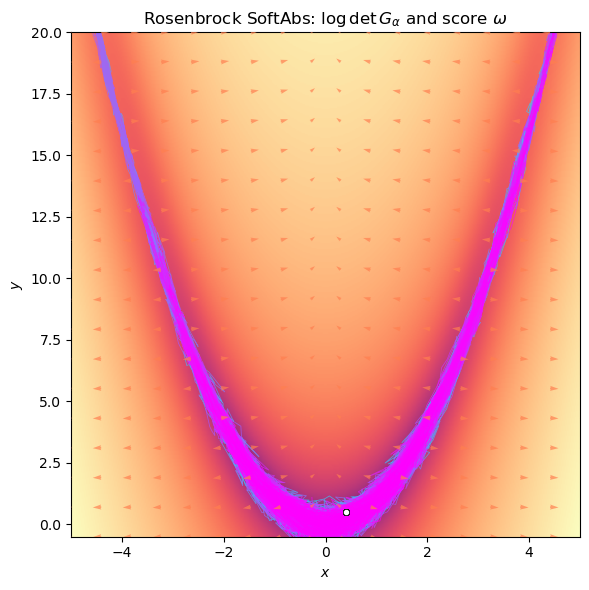

In [31]:
grid_fine   = 400
grid_coarse = 18

xg = np.linspace(-5, 5, grid_fine)
yg = np.linspace(-0.5, 20, grid_fine)
xx, yy = np.meshgrid(xg, yg)

xg_c = np.linspace(-5, 5, grid_coarse)
yg_c = np.linspace(-0.5, 20, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)

pts_fine   = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
pts_coarse = torch.tensor(pts_c_flat, dtype=torch.float32)

score    = RosenbrockScore()
cometric = RosenbrockSoftAbs()

with torch.no_grad():
    G          = cometric.metric_tensor(pts_fine)
    det_G      = torch.linalg.det(G).numpy()
    score_vecs = score(pts_coarse).detach().numpy()

log_det_G = np.log(det_G).reshape(grid_fine, grid_fine)

norms = np.linalg.norm(score_vecs, axis=1, keepdims=True)
score_vecs_unit = score_vecs / (norms + 1e-8)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
)

ax.quiver(
    pts_c_flat[:, 0], pts_c_flat[:, 1],
    score_vecs_unit[:, 0], score_vecs_unit[:, 1],
    color="coral", alpha=0.7, zorder=3,
    angles="xy", scale_units="xy", scale=6, width=0.004,
)

# --- Trajectories ---
colors = cm.cool(np.linspace(0.2, 1.0, traj_fhmc_rf.shape[0]))
for i in range(traj_fhmc_rf.shape[0]):
    ax.plot(traj_fhmc_rf[i, :, 0].numpy(), traj_fhmc_rf[i, :, 1].numpy(),
            c=colors[i], linewidth=0.6, alpha=0.7)

ax.scatter(traj_fhmc_rf[:, 0, 0].numpy(), traj_fhmc_rf[:, 0, 1].numpy(),
           c="white", s=20, zorder=5, edgecolors="black", linewidths=0.5)

ax.set_title(r"Rosenbrock SoftAbs: $\log \det G_{\alpha}$ and score $\omega$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

## Autocorrelation comparison

Sampler                         ESS x     ESS y
──────────────────────────────────────────────────
RHMC                            383.0     481.0
FHMC (reduced flip)             403.6     566.6
FHMC (no reduced flip)          411.0     551.2


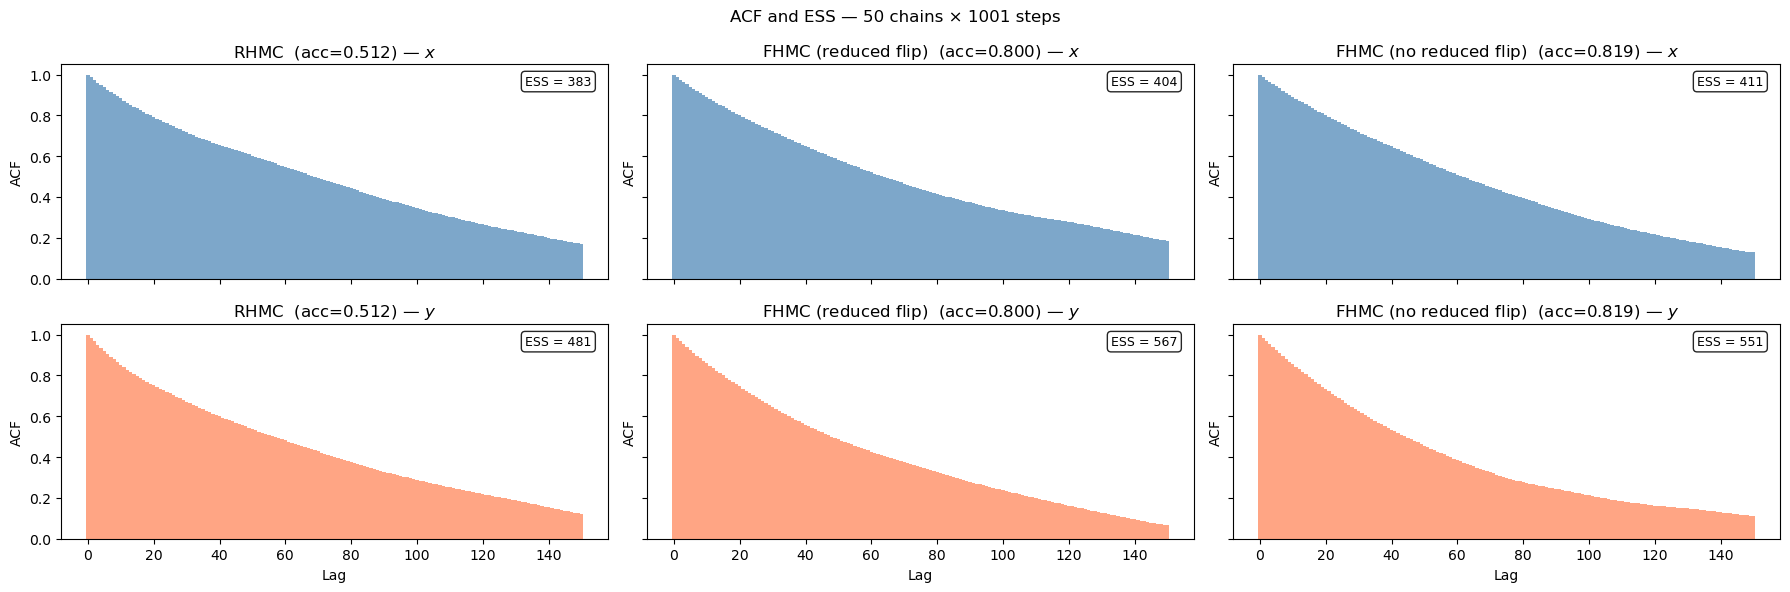

In [38]:
def acf(chain, max_lag):
    """Normalized autocorrelation at lags 0..max_lag for a 1D array."""
    chain = chain - chain.mean()
    var = np.var(chain)
    return np.array([
        np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
        for k in range(max_lag + 1)
    ])

def ess_from_chain(chain, max_lag):
    """
    ESS = N / IAT,  IAT = 1 + 2 * sum_{k>=1} ACF(k).
    Sum truncated at the first negative lag (Geyer's initial positive sequence).
    """
    ac = acf(chain, max_lag)
    first_neg = np.argmax(ac[1:] < 0)
    cutoff = first_neg if first_neg > 0 else max_lag
    iat = 1.0 + 2.0 * ac[1:cutoff + 1].sum()
    return len(chain) / max(iat, 1.0)

def mean_acf(traj, dim, max_lag):
    """Average ACF over all chains for a given coordinate dimension."""
    return np.mean([acf(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])], axis=0)

def total_ess(traj, dim, max_lag):
    """Total ESS summed over all chains for a given coordinate dimension."""
    return sum(ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0]))

max_lag = 150
lags    = np.arange(max_lag + 1)
n_chains, n_steps = traj_rhmc.shape[0], traj_rhmc.shape[1]
N_total = n_chains * n_steps

# ── ESS summary table ────────────────────────────────────────────────────────
print(f"{'Sampler':<28} {'ESS x':>8}  {'ESS y':>8}")
print("─" * 50)
for traj, label in [
    (traj_rhmc,    "RHMC"),
    (traj_fhmc_rf, "FHMC (reduced flip)"),
    (traj_fhmc,    "FHMC (no reduced flip)"),
]:
    ex = total_ess(traj, dim=0, max_lag=max_lag)
    ey = total_ess(traj, dim=1, max_lag=max_lag)
    print(f"{label:<28} {ex:8.1f}  {ey:8.1f}")

# ── ACF plots with ESS annotation ────────────────────────────────────────────
coords = [("$x$", 0, "steelblue"), ("$y$", 1, "coral")]
fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharey=True, sharex=True)

for row, (coord_name, dim, color) in enumerate(coords):
    for col, (traj, acc, label) in enumerate([
        (traj_rhmc,    acc_rhmc,    "RHMC"),
        (traj_fhmc_rf, acc_fhmc_rf, "FHMC (reduced flip)"),
        (traj_fhmc,    acc_fhmc,    "FHMC (no reduced flip)"),
    ]):
        ac      = mean_acf(traj, dim, max_lag)
        ess_val = total_ess(traj, dim, max_lag)
        ax = axes[row, col]
        ax.bar(lags, ac, width=1.0, color=color, alpha=0.7)
        ax.axhline(0, color="k", linewidth=0.6)
        ax.set_title(f"{label}  (acc={acc:.3f}) — {coord_name}")
        ax.set_ylabel("ACF")
        ax.text(0.97, 0.95, f"ESS = {ess_val:.0f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

for ax in axes[1]:
    ax.set_xlabel("Lag")
plt.suptitle(f"ACF and ESS — {n_chains} chains × {n_steps} steps", fontsize=12)
plt.tight_layout()
plt.show()